In [1]:
from google.colab import files
uploaded = files.upload()

Saving churn_boosting.csv to churn_boosting.csv


AdaBoost AUC: 1.0
Gradient Boosting AUC: 1.0


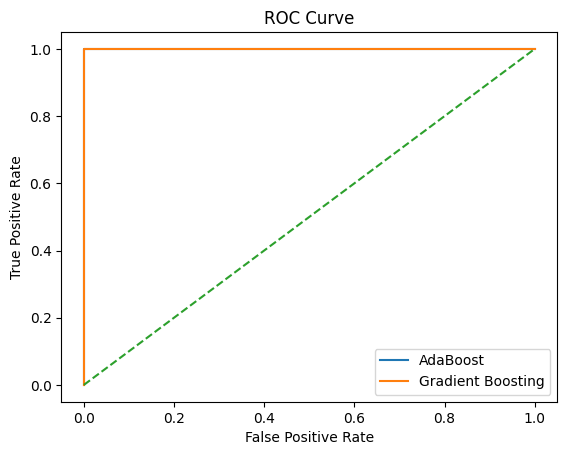

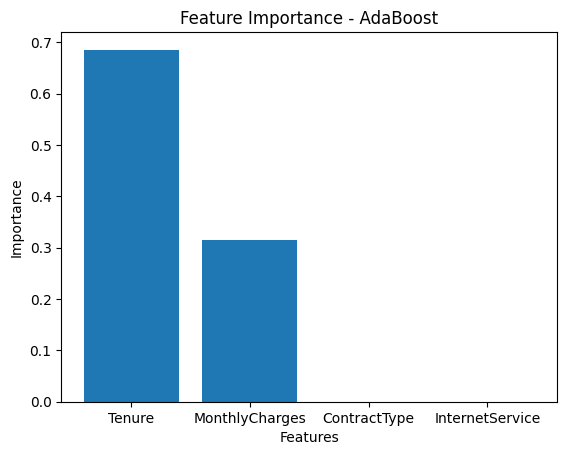

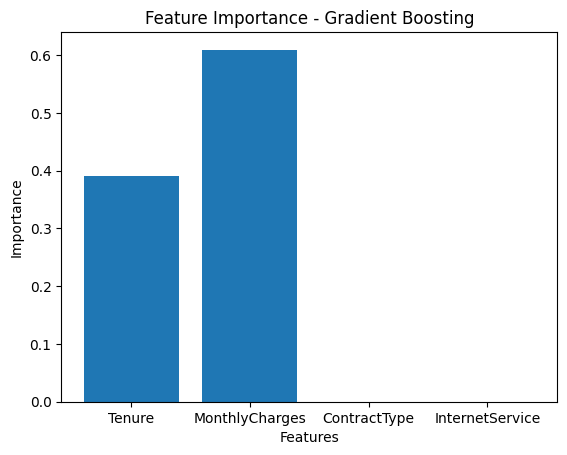

In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_curve, auc

from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

# -------------------------------
# 1. Load Dataset
# -------------------------------
df = pd.read_csv("churn_boosting.csv")

# -------------------------------
# 2. Preprocessing
# -------------------------------
le = LabelEncoder()

df['ContractType'] = le.fit_transform(df['ContractType'])
df['InternetService'] = le.fit_transform(df['InternetService'])
df['Churn'] = le.fit_transform(df['Churn'])  # Yes=1, No=0

# -------------------------------
# 3. Features and Target
# -------------------------------
X = df[['Tenure', 'MonthlyCharges', 'ContractType', 'InternetService']]
y = df['Churn']

# -------------------------------
# 4. Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------
# 5. Train AdaBoost
# -------------------------------
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    random_state=42
)

ada_model.fit(X_train, y_train)

# -------------------------------
# 6. Train Gradient Boosting
# -------------------------------
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)

# -------------------------------
# 7. Compare Performance (ROC-AUC)
# -------------------------------
# AdaBoost
y_prob_ada = ada_model.predict_proba(X_test)[:, 1]
fpr_ada, tpr_ada, _ = roc_curve(y_test, y_prob_ada)
auc_ada = auc(fpr_ada, tpr_ada)

# Gradient Boosting
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
auc_gb = auc(fpr_gb, tpr_gb)

print("AdaBoost AUC:", auc_ada)
print("Gradient Boosting AUC:", auc_gb)

# -------------------------------
# 8. ROC Curve Visualization
# -------------------------------
plt.figure()
plt.plot(fpr_ada, tpr_ada, label="AdaBoost")
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting")
plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# -------------------------------
# 9. Feature Importance Plot
# -------------------------------
features = X.columns

# AdaBoost Feature Importance
plt.figure()
plt.bar(features, ada_model.feature_importances_)
plt.title("Feature Importance - AdaBoost")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

# Gradient Boosting Feature Importance
plt.figure()
plt.bar(features, gb_model.feature_importances_)
plt.title("Feature Importance - Gradient Boosting")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()